In [ ]:
# Install all libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib \
alibi captum pdpbox eli5 imbalanced-learn sdv


Loading the dataset

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset (update if using expanded version)
dataset_path = '/content/drive/MyDrive/Crop_recommendation.csv'

# Load dataset with basic error handling
try:
    df = pd.read_csv(dataset_path)
    print(" Dataset loaded successfully.")
    print("Shape of dataset:", df.shape)
    display(df.head())  # More readable in Colab than df.head() alone
except Exception as e:
    print(" Failed to load dataset:", e)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Dataset loaded successfully.
Shape of dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Data inspection

In [ ]:
# Basic dataset information
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Basic descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Unique crops in the dataset
print("\nUnique Crops:")
print(df['label'].unique())

# Number of unique crops
print("\nNumber of unique crops:", df['label'].nunique())

# Count of samples per crop
print("\nSamples per Crop:")
print(df['label'].value_counts())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Missing Values per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Descriptive Statistics:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.14

Test-train data split

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['label'])
y = df['label']

# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1760, 7)
Test size: (440, 7)


Case 1 - Individual feature selection -> ensemble algorithm

In [ ]:
# Combinations to be tried:
# LogReg + SHAP
# XGBoost + SHAP
# RandomForest + SHAP
# SVM + LIME
# MLP + LIME
# === Imports ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# === Label Encoding for target ===
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# === Dictionary to store trained models ===
trained_models = {}

# === 1. Logistic Regression ===
logreg = LogisticRegression(max_iter=1000, solver='liblinear')  # removed multi_class to avoid deprecation warning
logreg.fit(X_train, y_train_encoded)
trained_models['Logistic Regression'] = logreg

# === 2. XGBoost ===
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train_encoded)
trained_models['XGBoost'] = xgb

# === 3. RandomForest ===
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train_encoded)
trained_models['RandomForest'] = rf

# === 4. SVM (Linear) ===
svm = SVC(kernel='linear', probability=True)  # probability=True needed for LIME
svm.fit(X_train, y_train_encoded)
trained_models['SVM (Linear)'] = svm

# === 5. MLPClassifier ===
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train_encoded)
trained_models['MLPClassifier'] = mlp

# === Print training completion status ===
print(" Model training complete:\n")
for model_name, model in trained_models.items():
    acc = model.score(X_train, y_train_encoded)
    print(f"{model_name:20s} - Train Accuracy: {round(acc * 100, 6)}%")


 Model training complete:

Logistic Regression  - Train Accuracy: 96.079545%
XGBoost              - Train Accuracy: 100.0%
RandomForest         - Train Accuracy: 100.0%
SVM (Linear)         - Train Accuracy: 99.261364%
MLPClassifier        - Train Accuracy: 98.181818%


Generate feature imp

In [ ]:
import shap
import numpy as np
import pandas as pd

# Wrap predict_proba to fix column name warning
def predict_fn(X):
    return logreg_model.predict_proba(pd.DataFrame(X, columns=X_train.columns))

# Background sample for SHAP
X_background = shap.utils.sample(X_train, 100, random_state=42)

# Initialize KernelExplainer
explainer = shap.KernelExplainer(predict_fn, X_background)

# Compute SHAP values
shap_values = explainer.shap_values(X_train, nsamples=100)

# Confirm SHAP shape
print("len(shap_values):", len(shap_values))
print("shap_values[0].shape:", shap_values[0].shape)

# Convert to NumPy array of shape (n_samples, n_features, n_classes)
shap_array = np.array(shap_values)  # shape: (n_samples, n_features, n_classes)

# Compute mean absolute SHAP value per feature across all samples and all classes
mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))  # now shape = (7,)

# Create pandas Series for feature importance
feature_importance = pd.Series(mean_abs_shap, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# Show final ranked features
print("✅ SHAP Feature Importance for Logistic Regression:")
display(feature_importance)


  0%|          | 0/1760 [00:00<?, ?it/s]

len(shap_values): 1760
shap_values[0].shape: (7, 22)
✅ SHAP Feature Importance for Logistic Regression:


,0
P,0.030421
K,0.030357
rainfall,0.026430
humidity,0.025362
N,0.021956
temperature,0.013146
ph,0.007197


Top k features testing on logreg model

✅ Best k (by CV F1, then CV Acc): 6
Features: ['P', 'K', 'rainfall', 'humidity', 'N', 'temperature']
CV  → Acc: 0.9699 | F1w: 0.9697
Test→ Acc: 0.9750 | F1w: 0.9749


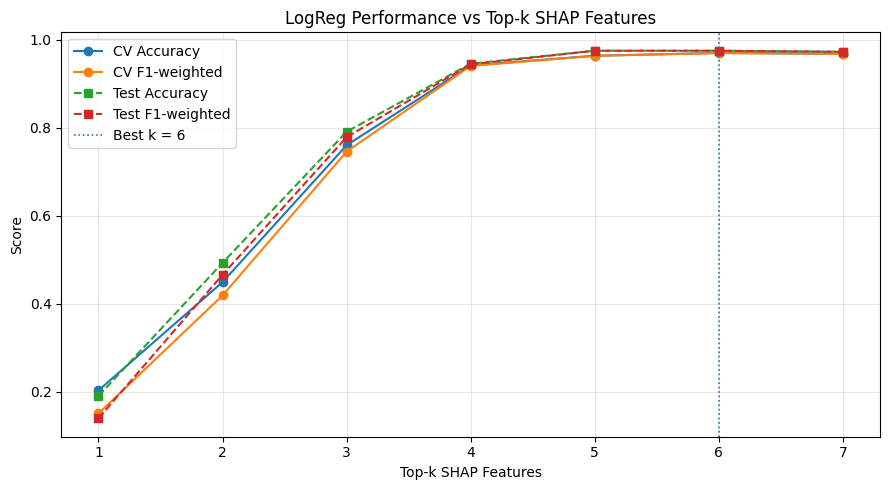

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[P],0.203409,0.151072,0.190909,0.139977
1,2,"[P, K]",0.449432,0.419137,0.493182,0.466123
2,3,"[P, K, rainfall]",0.760227,0.745770,0.790909,0.778609
3,4,"[P, K, rainfall, humidity]",0.941477,0.940552,0.945455,0.944086
4,5,"[P, K, rainfall, humidity, N]",0.963636,0.963209,0.975000,0.974896
5,6,"[P, K, rainfall, humidity, N, temperature]",0.969886,0.969667,0.975000,0.974890
6,7,"[P, K, rainfall, humidity, N, temperature, ph]",0.968182,0.967824,0.972727,0.972464


In [ ]:
# ==== LogReg + SHAP top-k loop (CV + final test) ====
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# ordered_features = list(feature_importance.index)
# X_train, X_test, y_train, y_test already defined

def make_model(class_weight=None, C=1.0, solver="lbfgs"):
    # NOTE: multi_class is intentionally NOT set to avoid the deprecation warning
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(
            max_iter=1000,
            solver=solver,          # lbfgs supports multinomial automatically
            C=C,
            class_weight=class_weight
        ))
    ])

CLASS_WEIGHT = None  # or "balanced" if needed
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ordered_features = list(feature_importance.index)
rows = []
n_feats = len(ordered_features)

for k in range(1, n_feats + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    model = make_model(class_weight=CLASS_WEIGHT)

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    acc_cv = cross_val_score(model, Xtr_k, y_train, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model, Xtr_k, y_train, scoring="f1_weighted", cv=cv).mean()

    model.fit(Xtr_k, y_train)
    y_pred = model.predict(Xte_k)
    acc_te = accuracy_score(y_test, y_pred)
    f1w_te = f1_score(y_test, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)
best_row = results_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k = int(best_row["k_features"])
best_feats = best_row["features_used"]

print(f"✅ Best k (by CV F1, then CV Acc): {best_k}")
print("Features:", best_feats)
print(f"CV  → Acc: {best_row['cv_accuracy']:.4f} | F1w: {best_row['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_row['test_accuracy']:.4f} | F1w: {best_row['test_f1_weighted']:.4f}")

plt.figure(figsize=(9,5))
plt.plot(results_df["k_features"], results_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_df["k_features"], results_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_df["k_features"], results_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_df["k_features"], results_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k, linestyle=':', linewidth=1.2, label=f"Best k = {best_k}")
plt.xlabel("Top-k SHAP Features")
plt.ylabel("Score")
plt.title("LogReg Performance vs Top-k SHAP Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

results_df.head(10)


XGB + SHAP

✅ XGB SHAP feature ranking (top 10):


,0
humidity,0.963410
rainfall,0.911248
P,0.717897
N,0.523853
K,0.439101
temperature,0.234953
ph,0.128310



🏆 XGB Best k (by CV F1 → CV Acc): 7
Features: ['humidity', 'rainfall', 'P', 'N', 'K', 'temperature', 'ph']
CV  → Acc: 0.9909 | F1w: 0.9909
Test→ Acc: 0.9932 | F1w: 0.9931


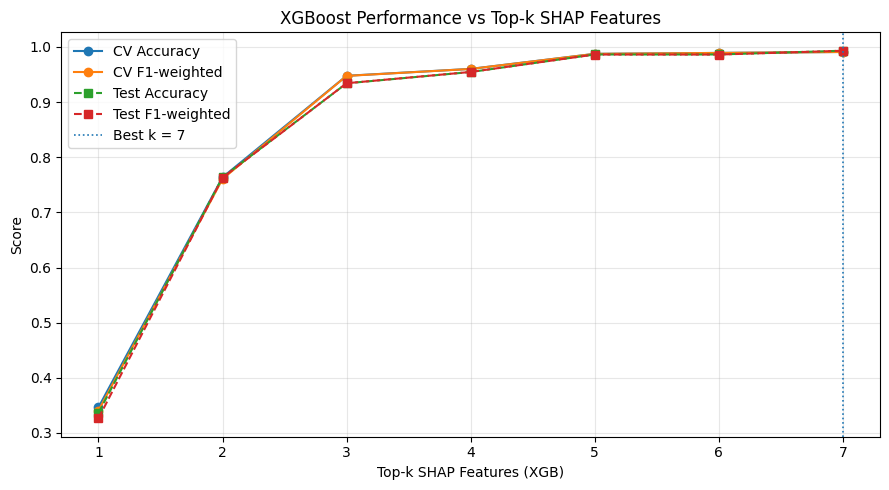

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[humidity],0.346591,0.340753,0.336364,0.326561
1,2,"[humidity, rainfall]",0.763636,0.760601,0.763636,0.762911
2,3,"[humidity, rainfall, P]",0.947727,0.947511,0.934091,0.934244
3,4,"[humidity, rainfall, P, N]",0.960227,0.960126,0.954545,0.954659
4,5,"[humidity, rainfall, P, N, K]",0.987500,0.987422,0.986364,0.986272
5,6,"[humidity, rainfall, P, N, K, temperature]",0.989205,0.989147,0.986364,0.986220
6,7,"[humidity, rainfall, P, N, K, temperature, ph]",0.990909,0.990889,0.993182,0.993116


In [ ]:
# ==== XGBoost + SHAP (TreeExplainer, model_output='raw') + top-k loop ====
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Assumes: xgb (trained XGBClassifier), X_train, X_test, y_train_encoded, y_test_encoded

# 1) SHAP with TreeExplainer → use RAW margins (required with tree_path_dependent)
explainer_xgb = shap.TreeExplainer(xgb, model_output="raw")  # <-- fixed
shap_values = explainer_xgb.shap_values(X_train)

# 2) Mean |SHAP| per feature across samples & classes (shape-agnostic)
def mean_abs_shap_from_any(shap_vals):
    if isinstance(shap_vals, list):
        arr = np.stack(shap_vals, axis=2)  # (n_samples, n_features, n_classes)
        return np.abs(arr).mean(axis=(0, 2))
    arr = np.array(shap_vals)
    if arr.ndim == 3:
        return np.abs(arr).mean(axis=(0, 2))
    elif arr.ndim == 2:
        return np.abs(arr).mean(axis=0)
    raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

mean_abs_shap_xgb = mean_abs_shap_from_any(shap_values)

feature_importance_xgb = pd.Series(mean_abs_shap_xgb, index=X_train.columns).sort_values(ascending=False)
print("✅ XGB SHAP feature ranking (top 10):")
display(feature_importance_xgb.head(10))

# 3) Top-k loop (reuse original hyperparams; create a fresh estimator each time)
def fresh_xgb_like(trained_xgb: XGBClassifier) -> XGBClassifier:
    # get_xgb_params() returns the XGBoost-native params (safe to re-init)
    return XGBClassifier(**trained_xgb.get_xgb_params())

ordered_features = list(feature_importance_xgb.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    model_k = fresh_xgb_like(xgb)

    # CV on training set
    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    # Fit on full train and evaluate on test
    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_xgb_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

# 4) Best k by CV F1 → CV Acc → smaller k
best_xgb = results_xgb_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_xgb = int(best_xgb["k_features"])
best_feats_xgb = best_xgb["features_used"]

print(f"\n🏆 XGB Best k (by CV F1 → CV Acc): {best_k_xgb}")
print("Features:", best_feats_xgb)
print(f"CV  → Acc: {best_xgb['cv_accuracy']:.4f} | F1w: {best_xgb['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_xgb['test_accuracy']:.4f} | F1w: {best_xgb['test_f1_weighted']:.4f}")

# 5) Plot curves
plt.figure(figsize=(9,5))
plt.plot(results_xgb_df["k_features"], results_xgb_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_xgb_df["k_features"], results_xgb_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_xgb_df["k_features"], results_xgb_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_xgb_df["k_features"], results_xgb_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_xgb, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_xgb}")
plt.xlabel("Top-k SHAP Features (XGB)")
plt.ylabel("Score")
plt.title("XGBoost Performance vs Top-k SHAP Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

results_xgb_df.head(10)


Random forest + SHAP

✅ RF SHAP feature ranking (top 10):


,0
humidity,0.032354
K,0.027706
rainfall,0.025991
N,0.025946
P,0.024081
temperature,0.010551
ph,0.005100



🏆 RF Best k (by CV F1 → CV Acc): 6
Features: ['humidity', 'K', 'rainfall', 'N', 'P', 'temperature']
CV  → Acc: 0.9943 | F1w: 0.9943
Test→ Acc: 0.9886 | F1w: 0.9886


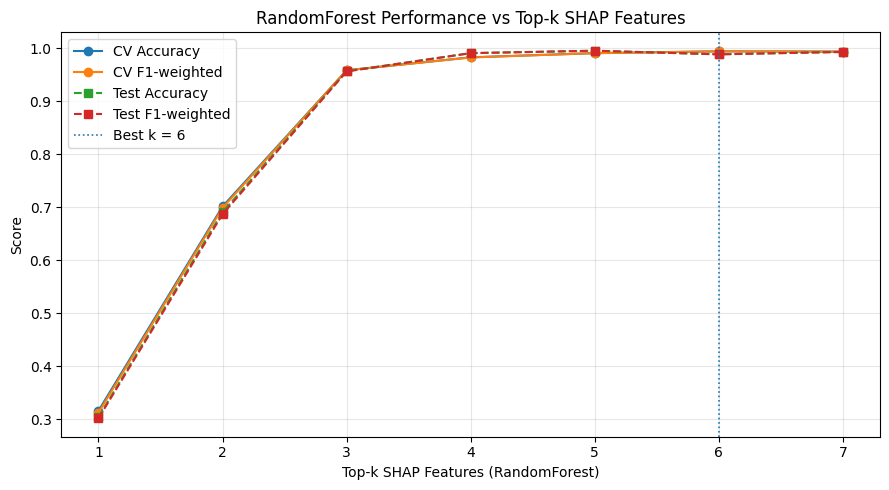

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[humidity],0.316477,0.312820,0.304545,0.302060
1,2,"[humidity, K]",0.701705,0.699054,0.690909,0.687026
2,3,"[humidity, K, rainfall]",0.958523,0.958506,0.956818,0.956320
3,4,"[humidity, K, rainfall, N]",0.982955,0.982748,0.990909,0.990843
4,5,"[humidity, K, rainfall, N, P]",0.990909,0.990764,0.995455,0.995452
5,6,"[humidity, K, rainfall, N, P, temperature]",0.994318,0.994277,0.988636,0.988612
6,7,"[humidity, K, rainfall, N, P, temperature, ph]",0.993750,0.993730,0.993182,0.993178


In [ ]:
# ==== RandomForest + SHAP (TreeExplainer, model_output='raw') + top-k loop ====
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone
import matplotlib.pyplot as plt

# Assumes:
# - rf (trained RandomForestClassifier) exists; otherwise uncomment the two lines below:
# rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train_encoded)

# ----- 1) SHAP with TreeExplainer on RF -----
# Note: for tree models, using raw margins avoids the probability+tree_path constraint
explainer_rf = shap.TreeExplainer(rf, model_output="raw")
shap_values_rf = explainer_rf.shap_values(X_train)

# Helper to be shape-agnostic across binary/multiclass SHAP formats
def mean_abs_shap_from_any(shap_vals):
    if isinstance(shap_vals, list):           # list per class -> stack on last axis
        arr = np.stack(shap_vals, axis=2)     # (n_samples, n_features, n_classes)
        return np.abs(arr).mean(axis=(0, 2))
    arr = np.array(shap_vals)
    if arr.ndim == 3:                         # (n_samples, n_features, n_classes)
        return np.abs(arr).mean(axis=(0, 2))
    elif arr.ndim == 2:                       # (n_samples, n_features)
        return np.abs(arr).mean(axis=0)
    raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

mean_abs_shap_rf = mean_abs_shap_from_any(shap_values_rf)

# ----- 2) SHAP ranking -----
feature_importance_rf = pd.Series(mean_abs_shap_rf, index=X_train.columns).sort_values(ascending=False)
print("✅ RF SHAP feature ranking (top 10):")
display(feature_importance_rf.head(10))

# ----- 3) Top-k loop with 5-fold CV + final Test -----
ordered_features = list(feature_importance_rf.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]

    # fresh RF each time with same hyperparameters as the trained one
    model_k = clone(rf)

    # CV on training split
    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    # Fit on full train and evaluate on test
    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_rf_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

# ----- 4) Best k selection by CV F1 → CV Acc → smaller k -----
best_rf = results_rf_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_rf = int(best_rf["k_features"])
best_feats_rf = best_rf["features_used"]

print(f"\n🏆 RF Best k (by CV F1 → CV Acc): {best_k_rf}")
print("Features:", best_feats_rf)
print(f"CV  → Acc: {best_rf['cv_accuracy']:.4f} | F1w: {best_rf['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_rf['test_accuracy']:.4f} | F1w: {best_rf['test_f1_weighted']:.4f}")

# ----- 5) Plots -----
plt.figure(figsize=(9,5))
plt.plot(results_rf_df["k_features"], results_rf_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_rf_df["k_features"], results_rf_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_rf_df["k_features"], results_rf_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_rf_df["k_features"], results_rf_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_rf, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_rf}")
plt.xlabel("Top-k SHAP Features (RandomForest)")
plt.ylabel("Score")
plt.title("RandomForest Performance vs Top-k SHAP Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: inspect the table
results_rf_df.head(10)


SVM + LIME

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=885973783d0c79a1785a6af45b7f8c3ffe6f81fc8fd4b7e0766bd7cedcfbd770
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
✅ SVM+LIME global feature importance (top 10):


,0
P,0.072039
N,0.062157
ph,0.029299
humidity,0.025701
rainfall,0.020055
temperature,0.013976
K,0.013769



🏆 SVM+LIME Best k: 7
Features: ['P', 'N', 'ph', 'humidity', 'rainfall', 'temperature', 'K']
CV  → Acc: 0.9818 | F1w: 0.9815
Test→ Acc: 0.9818 | F1w: 0.9817


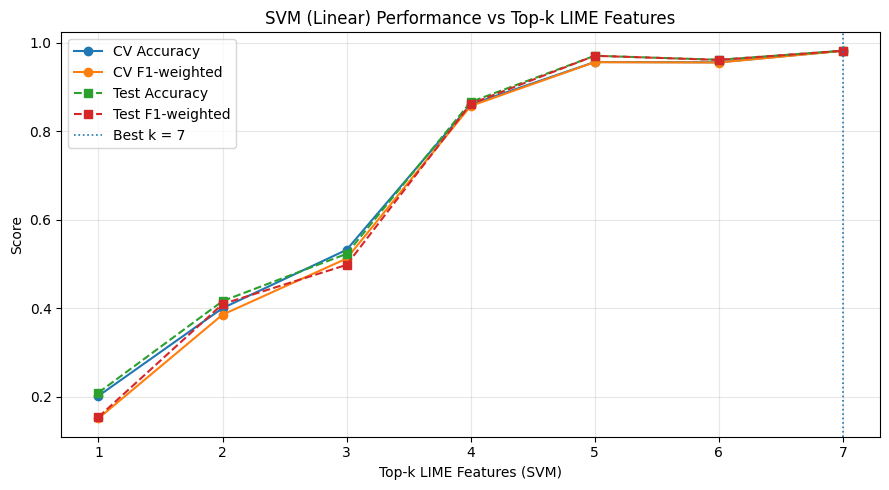

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[P],0.201705,0.150936,0.209091,0.154008
1,2,"[P, N]",0.400000,0.385236,0.415909,0.409214
2,3,"[P, N, ph]",0.531818,0.512062,0.522727,0.497761
3,4,"[P, N, ph, humidity]",0.860227,0.856892,0.865909,0.861623
4,5,"[P, N, ph, humidity, rainfall]",0.956250,0.955871,0.970455,0.970350
5,6,"[P, N, ph, humidity, rainfall, temperature]",0.955682,0.955092,0.961364,0.961026
6,7,"[P, N, ph, humidity, rainfall, temperature, K]",0.981818,0.981505,0.981818,0.981715


In [ ]:
# ==== SVM + LIME (global importance via averaged local weights) + top-k loop ====
# If lime isn't installed, uncomment the next line:
# !pip -q install lime

!pip install lime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from lime.lime_tabular import LimeTabularExplainer

# Assumes you already have:
# X_train, X_test, y_train_encoded, y_test_encoded, label_encoder

# 1) Build SVM pipeline (scaling is crucial for SVM)
def make_svm(C=1.0, class_weight=None):
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", SVC(kernel="linear", C=C, probability=True, class_weight=class_weight))  # probability=True for LIME
    ])

svm_pipe = make_svm(C=1.0, class_weight=None)
svm_pipe.fit(X_train, y_train_encoded)

# 2) LIME explainer setup
feature_names = list(X_train.columns)
class_names = [str(c) for c in label_encoder.classes_]  # purely cosmetic for LIME UI
explainer = LimeTabularExplainer(
    training_data=X_train.values.astype(float),
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode="classification",
    sample_around_instance=True,
    random_state=42
)

# 3) Build GLOBAL LIME importance by averaging |weights| across many instances & classes
def global_lime_importance(model, X, m_instances=200, num_features=None):
    """
    Returns a pandas Series of mean absolute LIME weights per feature.
    - model: must expose predict_proba on numpy arrays
    - X: DataFrame
    - m_instances: how many train rows to sample for explanations
    - num_features: number of features to request from LIME per instance
    """
    num_features = num_features or X.shape[1]
    m = min(m_instances, len(X))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=m, replace=False)
    agg = np.zeros(X.shape[1], dtype=float)
    counts = np.zeros(X.shape[1], dtype=float)

    for i in idx:
        exp = explainer.explain_instance(
            data_row=X.iloc[i].values.astype(float),
            predict_fn=lambda z: model.predict_proba(pd.DataFrame(z, columns=X.columns)),
            num_features=num_features
        )
        # exp.as_map() returns dict: {label: [(feat_idx, weight), ...], ...}
        amap = exp.as_map()
        for label, feats in amap.items():
            for j, w in feats:
                agg[j] += abs(w)
                counts[j] += 1.0

    # avoid division by zero
    counts[counts == 0] = 1.0
    mean_abs = agg / counts
    return pd.Series(mean_abs, index=X.columns).sort_values(ascending=False)

feature_importance_lime = global_lime_importance(svm_pipe, X_train, m_instances=200)
print("✅ SVM+LIME global feature importance (top 10):")
display(feature_importance_lime.head(10))

# 4) Top-k loop using SVM (same idea as SHAP loops)
ordered_features = list(feature_importance_lime.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    model_k = make_svm(C=1.0, class_weight=None)

    # CV on training split
    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    # Fit on full train and evaluate on test
    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_svm_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

# 5) Select best k by CV F1 → CV Acc → smaller k
best_svm = results_svm_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_svm = int(best_svm["k_features"])
best_feats_svm = best_svm["features_used"]

print(f"\n🏆 SVM+LIME Best k: {best_k_svm}")
print("Features:", best_feats_svm)
print(f"CV  → Acc: {best_svm['cv_accuracy']:.4f} | F1w: {best_svm['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_svm['test_accuracy']:.4f} | F1w: {best_svm['test_f1_weighted']:.4f}")

# 6) Plot curves
plt.figure(figsize=(9,5))
plt.plot(results_svm_df["k_features"], results_svm_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_svm_df["k_features"], results_svm_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_svm_df["k_features"], results_svm_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_svm_df["k_features"], results_svm_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_svm, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_svm}")
plt.xlabel("Top-k LIME Features (SVM)")
plt.ylabel("Score")
plt.title("SVM (Linear) Performance vs Top-k LIME Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: see first rows
results_svm_df.head(10)


MLP + lime

✅ MLP+LIME global feature importance (top 10):


,0
P,0.074293
N,0.073019
humidity,0.032210
ph,0.031870
rainfall,0.024047
temperature,0.019705
K,0.010302



🏆 MLP+LIME Best k: 7
Features: ['P', 'N', 'humidity', 'ph', 'rainfall', 'temperature', 'K']
CV  → Acc: 0.9710 | F1w: 0.9709
Test→ Acc: 0.9795 | F1w: 0.9794


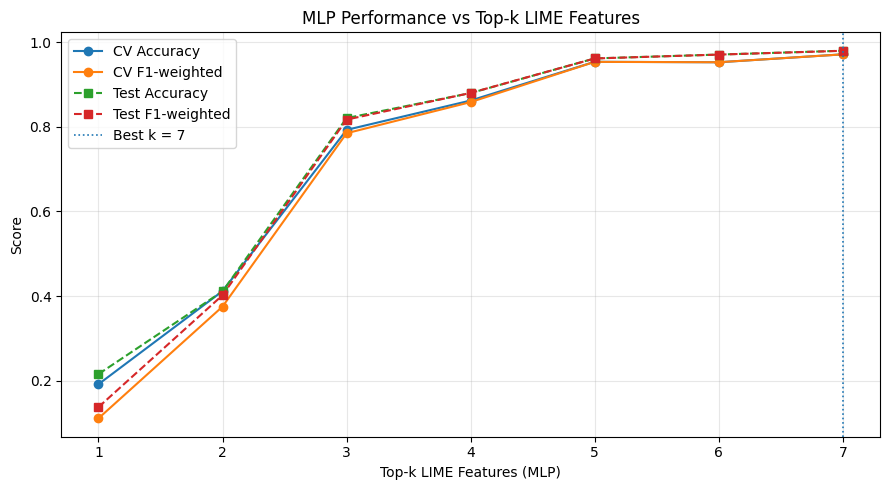

,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,1,[P],0.192045,0.111443,0.215909,0.137962
1,2,"[P, N]",0.411932,0.375372,0.411364,0.402222
2,3,"[P, N, humidity]",0.792614,0.784661,0.820455,0.816860
3,4,"[P, N, humidity, ph]",0.861932,0.858220,0.879545,0.879806
4,5,"[P, N, humidity, ph, rainfall]",0.953409,0.953188,0.961364,0.961211
5,6,"[P, N, humidity, ph, rainfall, temperature]",0.952273,0.952327,0.970455,0.970370
6,7,"[P, N, humidity, ph, rainfall, temperature, K]",0.971023,0.970899,0.979545,0.979393


In [ ]:
# ==== MLP + LIME (global importance via averaged local weights) + top-k loop ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from lime.lime_tabular import LimeTabularExplainer

# Assumes: X_train, X_test, y_train_encoded, y_test_encoded, label_encoder already exist

# 1) Build MLP pipeline (scaling is important for MLP)
def make_mlp(hidden=(100,), alpha=1e-4, lr_init=1e-3, early_stop=True, random_state=42):
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=hidden,
            activation="relu",
            solver="adam",
            alpha=alpha,
            learning_rate_init=lr_init,
            max_iter=1000,
            early_stopping=early_stop,
            n_iter_no_change=20,
            validation_fraction=0.1,
            random_state=random_state,
            verbose=False
        ))
    ])

mlp_pipe = make_mlp(hidden=(128, 64), alpha=1e-4, lr_init=1e-3, early_stop=True)
mlp_pipe.fit(X_train, y_train_encoded)

# 2) LIME explainer setup
feature_names = list(X_train.columns)
class_names = [str(c) for c in label_encoder.classes_]
explainer = LimeTabularExplainer(
    training_data=X_train.values.astype(float),
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode="classification",
    sample_around_instance=True,
    random_state=42
)

# 3) Global LIME importance by averaging |weights| across many instances
def global_lime_importance(model, X, m_instances=200, num_features=None):
    """
    Mean absolute LIME weight per feature (global importance).
    model: must expose predict_proba on numpy arrays (Pipeline OK).
    """
    num_features = num_features or X.shape[1]
    m = min(m_instances, len(X))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=m, replace=False)

    agg = np.zeros(X.shape[1], dtype=float)
    counts = np.zeros(X.shape[1], dtype=float)

    for i in idx:
        exp = explainer.explain_instance(
            data_row=X.iloc[i].values.astype(float),
            predict_fn=lambda z: model.predict_proba(pd.DataFrame(z, columns=X.columns)),
            num_features=num_features
        )
        amap = exp.as_map()  # {label: [(feat_idx, weight), ...], ...}
        for _, feats in amap.items():
            for j, w in feats:
                agg[j] += abs(w)
                counts[j] += 1.0

    counts[counts == 0] = 1.0
    mean_abs = agg / counts
    return pd.Series(mean_abs, index=X.columns).sort_values(ascending=False)

feature_importance_lime_mlp = global_lime_importance(mlp_pipe, X_train, m_instances=200)
print("✅ MLP+LIME global feature importance (top 10):")
display(feature_importance_lime_mlp.head(10))

# 4) Top-k loop
ordered_features = list(feature_importance_lime_mlp.index)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for k in range(1, len(ordered_features) + 1):
    feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
    if not feats:
        continue

    Xtr_k, Xte_k = X_train[feats], X_test[feats]
    model_k = make_mlp(hidden=(128, 64), alpha=1e-4, lr_init=1e-3, early_stop=True)

    # CV on training split
    acc_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
    f1w_cv = cross_val_score(model_k, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

    # Fit on full train and evaluate on test
    model_k.fit(Xtr_k, y_train_encoded)
    y_pred = model_k.predict(Xte_k)
    acc_te = accuracy_score(y_test_encoded, y_pred)
    f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

    rows.append({
        "k_features": k,
        "features_used": feats,
        "cv_accuracy": acc_cv,
        "cv_f1_weighted": f1w_cv,
        "test_accuracy": acc_te,
        "test_f1_weighted": f1w_te
    })

results_mlp_df = pd.DataFrame(rows).sort_values("k_features").reset_index(drop=True)

# 5) Select best k by CV F1 → CV Acc → smaller k
best_mlp = results_mlp_df.sort_values(
    by=["cv_f1_weighted", "cv_accuracy", "k_features"],
    ascending=[False, False, True]
).iloc[0]

best_k_mlp = int(best_mlp["k_features"])
best_feats_mlp = best_mlp["features_used"]

print(f"\n🏆 MLP+LIME Best k: {best_k_mlp}")
print("Features:", best_feats_mlp)
print(f"CV  → Acc: {best_mlp['cv_accuracy']:.4f} | F1w: {best_mlp['cv_f1_weighted']:.4f}")
print(f"Test→ Acc: {best_mlp['test_accuracy']:.4f} | F1w: {best_mlp['test_f1_weighted']:.4f}")

# 6) Plot curves
plt.figure(figsize=(9,5))
plt.plot(results_mlp_df["k_features"], results_mlp_df["cv_accuracy"], marker='o', label="CV Accuracy")
plt.plot(results_mlp_df["k_features"], results_mlp_df["cv_f1_weighted"], marker='o', label="CV F1-weighted")
plt.plot(results_mlp_df["k_features"], results_mlp_df["test_accuracy"], marker='s', linestyle='--', label="Test Accuracy")
plt.plot(results_mlp_df["k_features"], results_mlp_df["test_f1_weighted"], marker='s', linestyle='--', label="Test F1-weighted")
plt.axvline(best_k_mlp, linestyle=':', linewidth=1.2, label=f"Best k = {best_k_mlp}")
plt.xlabel("Top-k LIME Features (MLP)")
plt.ylabel("Score")
plt.title("MLP Performance vs Top-k LIME Features")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: peek at the table
results_mlp_df.head(10)


Case 1 compile results

In [ ]:
# ==== Compile & compare Model + XAI results (best-k per model) ====
import pandas as pd

def pick_best_row(df: pd.DataFrame):
    """Select best row by CV F1 → CV Acc → smaller k."""
    return (df.sort_values(
        by=["cv_f1_weighted", "cv_accuracy", "k_features"],
        ascending=[False, False, True]
    ).iloc[0])

# Map: friendly name -> results dataframe variable name
cand_dfs = {
    "LogReg + SHAP":      "results_df",        # from the LogReg loop
    "XGBoost + SHAP":     "results_xgb_df",
    "RandomForest + SHAP":"results_rf_df",
    "SVM (Linear) + LIME":"results_svm_df",
    "MLP + LIME":         "results_mlp_df",
}

rows = []
for name, var in cand_dfs.items():
    df = globals().get(var, None)
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        continue
    best = pick_best_row(df)
    rows.append({
        "model": name,
        "best_k": int(best["k_features"]),
        "features_used": ", ".join(best["features_used"]),
        "cv_accuracy": float(best["cv_accuracy"]),
        "cv_f1_weighted": float(best["cv_f1_weighted"]),
        "test_accuracy": float(best["test_accuracy"]),
        "test_f1_weighted": float(best["test_f1_weighted"]),
    })

summary_df = pd.DataFrame(rows)

# Order by test F1 then test Acc (desc)
summary_df = summary_df.sort_values(
    by=["test_f1_weighted", "test_accuracy"], ascending=[False, False]
).reset_index(drop=True)

print("✅ Best Model + XAI combos (by hold-out Test F1 → Test Acc):")
display(summary_df)

# Optional: also print a neat text summary
print("\n— Brief Comparison —")
for i, r in summary_df.iterrows():
    print(f"{i+1}. {r['model']:20s} | k={r['best_k']:>2} | "
          f"CV Acc={r['cv_accuracy']:.4f}  CV F1={r['cv_f1_weighted']:.4f}  | "
          f"Test Acc={r['test_accuracy']:.4f}  Test F1={r['test_f1_weighted']:.4f}")

# Optional: identify the overall champion
champ = summary_df.iloc[0]
print(f"\n Champion: {champ['model']}  | k={champ['best_k']}  "
      f"| Test Acc={champ['test_accuracy']:.4f}, Test F1={champ['test_f1_weighted']:.4f}")
print("Features used:", champ["features_used"])


✅ Best Model + XAI combos (by hold-out Test F1 → Test Acc):


,model,best_k,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,XGBoost + SHAP,7,"humidity, rainfall, P, N, K, temperature, ph",0.990909,0.990889,0.993182,0.993116
1,RandomForest + SHAP,6,"humidity, K, rainfall, N, P, temperature",0.994318,0.994277,0.988636,0.988612
2,SVM (Linear) + LIME,7,"P, N, ph, humidity, rainfall, temperature, K",0.981818,0.981505,0.981818,0.981715
3,MLP + LIME,7,"P, N, humidity, ph, rainfall, temperature, K",0.971023,0.970899,0.979545,0.979393
4,LogReg + SHAP,6,"P, K, rainfall, humidity, N, temperature",0.969886,0.969667,0.975000,0.974890



— Brief Comparison —
1. XGBoost + SHAP       | k= 7 | CV Acc=0.9909  CV F1=0.9909  | Test Acc=0.9932  Test F1=0.9931
2. RandomForest + SHAP  | k= 6 | CV Acc=0.9943  CV F1=0.9943  | Test Acc=0.9886  Test F1=0.9886
3. SVM (Linear) + LIME  | k= 7 | CV Acc=0.9818  CV F1=0.9815  | Test Acc=0.9818  Test F1=0.9817
4. MLP + LIME           | k= 7 | CV Acc=0.9710  CV F1=0.9709  | Test Acc=0.9795  Test F1=0.9794
5. LogReg + SHAP        | k= 6 | CV Acc=0.9699  CV F1=0.9697  | Test Acc=0.9750  Test F1=0.9749

🏆 Champion: XGBoost + SHAP  | k=7  | Test Acc=0.9932, Test F1=0.9931
Features used: humidity, rainfall, P, N, K, temperature, ph


Case 2 Ensemble feature selection + individual models

In [ ]:
# ==== Case 2: Step 1 - Normalize feature importance vectors ====

import pandas as pd

def normalize_importance(series: pd.Series, method="sum"):
    """
    Normalize a pandas Series of feature importances.
    - method="sum": each feature importance divided by sum → vector sums to 1
    - method="max": each feature importance divided by max → max=1
    """
    s = series.abs().copy()
    if method == "sum":
        return s / s.sum()
    elif method == "max":
        return s / s.max()
    else:
        raise ValueError("method must be 'sum' or 'max'")

# Normalize all feature importance vectors
logreg_norm   = normalize_importance(feature_importance, method="sum")
xgb_norm      = normalize_importance(feature_importance_xgb, method="sum")
rf_norm       = normalize_importance(feature_importance_rf, method="sum")
svm_norm      = normalize_importance(feature_importance_lime, method="sum")
mlp_norm      = normalize_importance(feature_importance_lime_mlp, method="sum")

# Combine into a single DataFrame for easy comparison
ensemble_norm_df = pd.DataFrame({
    "LogReg": logreg_norm,
    "XGB": xgb_norm,
    "RF": rf_norm,
    "SVM": svm_norm,
    "MLP": mlp_norm
}).fillna(0)

print("✅ Normalized feature importance vectors (sum=1 per model):")
display(ensemble_norm_df.round(4))


✅ Normalized feature importance vectors (sum=1 per model):


,LogReg,XGB,RF,SVM,MLP
K,0.1960,0.1121,0.1826,0.0581,0.0388
N,0.1418,0.1337,0.1710,0.2623,0.2751
P,0.1964,0.1832,0.1587,0.3040,0.2799
humidity,0.1638,0.2458,0.2132,0.1084,0.1213
ph,0.0465,0.0327,0.0336,0.1236,0.1201
rainfall,0.1707,0.2325,0.1713,0.0846,0.0906
temperature,0.0849,0.0600,0.0695,0.0590,0.0742


Ensemble feature methods and rankings

In [ ]:
# ==== Case 2: Step 2 - Build Ensemble Feature Rankings ====

import pandas as pd

# 1) Simple Average (mean of normalized importances)
ensemble_simple_avg = ensemble_norm_df.mean(axis=1).sort_values(ascending=False)

# 2) Rank Aggregation (average rank across models)
ranks_df = ensemble_norm_df.rank(ascending=False, method="average")  # rank features per model
ensemble_rank_avg = ranks_df.mean(axis=1).sort_values(ascending=True)  # lower = more important

# 3) Accuracy-Weighted Average
# -- Use best test accuracy (or weighted F1) from Case 1 for each model --
case1_test_acc = {
    "LogReg": 0.975,   # replace with your Case 1 test accuracy/F1
    "XGB":    0.993,
    "RF":     0.995,
    "SVM":    0.970,
    "MLP":    0.980
}

# Build weighted average
weights = pd.Series(case1_test_acc)
# Ensure same order as ensemble_norm_df columns
weights = weights[ensemble_norm_df.columns]
ensemble_acc_weighted = (ensemble_norm_df * weights).sum(axis=1) / weights.sum()
ensemble_acc_weighted = ensemble_acc_weighted.sort_values(ascending=False)

# ==== Display Results ====
print("✅ Ensemble Feature Rankings (Top 10):")

print("\n--- Simple Average ---")
display(ensemble_simple_avg)

print("\n--- Rank Aggregation (lower = better rank) ---")
display(ensemble_rank_avg)

print("\n--- Accuracy-Weighted Average ---")
display(ensemble_acc_weighted)


✅ Ensemble Feature Rankings (Top 10):

--- Simple Average ---


,0
P,0.224436
N,0.196760
humidity,0.170526
rainfall,0.149942
K,0.117516
ph,0.071303
temperature,0.069517



--- Rank Aggregation (lower = better rank) ---


,0
P,2.2
humidity,2.6
N,3.4
rainfall,3.6
K,4.6
ph,5.6
temperature,6.0



--- Accuracy-Weighted Average ---


,0
P,0.223993
N,0.196437
humidity,0.170989
rainfall,0.150338
K,0.117741
ph,0.071005
temperature,0.069497


Helper functions

✅ Case 2 — All results (first 20 rows):


,strategy,k_features,features_used,model,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted
0,AccWeighted,1,[P],LogReg,0.203409,0.151072,0.190909,0.139977
1,AccWeighted,2,"[P, N]",LogReg,0.394886,0.376064,0.390909,0.373221
2,AccWeighted,3,"[P, N, humidity]",LogReg,0.803977,0.797820,0.797727,0.793026
3,AccWeighted,4,"[P, N, humidity, rainfall]",LogReg,0.921023,0.920428,0.931818,0.931906
4,AccWeighted,5,"[P, N, humidity, rainfall, K]",LogReg,0.963636,0.963209,0.975000,0.974896
5,AccWeighted,6,"[P, N, humidity, rainfall, K, ph]",LogReg,0.961932,0.961443,0.984091,0.983933
6,AccWeighted,7,"[P, N, humidity, rainfall, K, ph, temperature]",LogReg,0.968182,0.967824,0.972727,0.972464
7,AccWeighted,1,[P],MLP,0.192045,0.111443,0.215909,0.137962
8,AccWeighted,2,"[P, N]",MLP,0.411932,0.375372,0.411364,0.402222
9,AccWeighted,3,"[P, N, humidity]",MLP,0.792614,0.784661,0.820455,0.816860


🏁 Case 2 — Best per (Model × Strategy):


,strategy,model,best_k,features_used,cv_acc,cv_f1,test_acc,test_f1
0,AccWeighted,RF,7,"P, N, humidity, rainfall, K, ph, temperature",0.995455,0.995433,0.995455,0.995452
1,SimpleAvg,RF,7,"P, N, humidity, rainfall, K, ph, temperature",0.995455,0.995433,0.995455,0.995452
2,RankAvg,RF,7,"P, humidity, N, rainfall, K, ph, temperature",0.994886,0.994854,0.993182,0.993178
3,AccWeighted,XGB,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.991444,0.993182,0.993116
4,RankAvg,XGB,7,"P, humidity, N, rainfall, K, ph, temperature",0.990341,0.990306,0.993182,0.993116
5,SimpleAvg,XGB,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.991444,0.993182,0.993116
6,AccWeighted,SVM,6,"P, N, humidity, rainfall, K, ph",0.981818,0.981498,0.990909,0.990817
7,RankAvg,SVM,6,"P, humidity, N, rainfall, K, ph",0.981818,0.981498,0.990909,0.990817
8,SimpleAvg,SVM,6,"P, N, humidity, rainfall, K, ph",0.981818,0.981498,0.990909,0.990817
9,RankAvg,MLP,7,"P, humidity, N, rainfall, K, ph, temperature",0.964773,0.964645,0.986364,0.986321


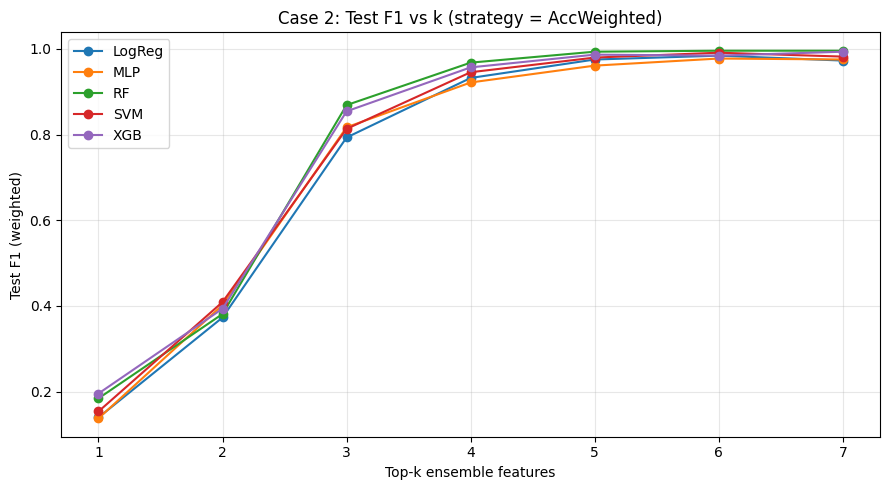

In [ ]:
# ==== Case 2: Step 3 — Train all models on ensemble feature rankings (top-k loop) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone

# ---------- Assumes these already exist from previous steps ----------
# X_train, X_test, y_train_encoded, y_test_encoded
# ensemble_simple_avg: pd.Series (higher = more important)
# ensemble_rank_avg:  pd.Series (lower  = more important)
# ensemble_acc_weighted: pd.Series (higher = more important)

# ---------- Helper: model builders (reuse your earlier hyperparams if available) ----------
def make_logreg():
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))
    ])

def make_xgb():
    # If a tuned/trained xgb exists, clone its params; else use a reasonable default
    try:
        return XGBClassifier(**xgb.get_xgb_params())
    except:
        return XGBClassifier(
            eval_metric="mlogloss",
            random_state=42,
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9
        )

def make_rf():
    try:
        return clone(rf)
    except:
        return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

def make_svm():
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", SVC(kernel="linear"))  # probability not required for eval
    ])

def make_mlp():
    return Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000,
                              early_stopping=True, n_iter_no_change=20,
                              validation_fraction=0.1, random_state=42))
    ])

MODELS = {
    "LogReg": make_logreg,
    "XGB": make_xgb,
    "RF": make_rf,
    "SVM": make_svm,
    "MLP": make_mlp,
}

# ---------- Helper: run top-k loop for one strategy ----------
def run_topk_for_strategy(strategy_name: str, feature_series: pd.Series):
    """
    strategy_name: "SimpleAvg" | "RankAvg" | "AccWeighted"
    feature_series: pd.Series indexed by feature name; larger is better EXCEPT for RankAvg where smaller is better
    """
    # Order features (RankAvg is ascending, others descending)
    if strategy_name == "RankAvg":
        ordered_features = list(feature_series.sort_values(ascending=True).index)
    else:
        ordered_features = list(feature_series.sort_values(ascending=False).index)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rows = []

    for k in range(1, len(ordered_features) + 1):
        feats = [f for f in ordered_features[:k] if f in X_train.columns and f in X_test.columns]
        if not feats:
            continue

        Xtr_k, Xte_k = X_train[feats], X_test[feats]

        for model_name, maker in MODELS.items():
            model = maker()

            # CV
            acc_cv = cross_val_score(model, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
            f1w_cv = cross_val_score(model, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()

            # Fit on full train & Test
            model.fit(Xtr_k, y_train_encoded)
            y_pred = model.predict(Xte_k)
            acc_te = accuracy_score(y_test_encoded, y_pred)
            f1w_te = f1_score(y_test_encoded, y_pred, average="weighted")

            rows.append({
                "strategy": strategy_name,
                "k_features": k,
                "features_used": feats,
                "model": model_name,
                "cv_accuracy": acc_cv,
                "cv_f1_weighted": f1w_cv,
                "test_accuracy": acc_te,
                "test_f1_weighted": f1w_te
            })

    return pd.DataFrame(rows)

# ---------- Run for the three strategies ----------
results_case2_simple = run_topk_for_strategy("SimpleAvg", ensemble_simple_avg)
results_case2_rank   = run_topk_for_strategy("RankAvg",   ensemble_rank_avg)
results_case2_accw   = run_topk_for_strategy("AccWeighted", ensemble_acc_weighted)

results_case2_all = pd.concat([results_case2_simple, results_case2_rank, results_case2_accw],
                              ignore_index=True)

# Sort for readability
results_case2_all = results_case2_all.sort_values(
    by=["strategy", "model", "k_features"]
).reset_index(drop=True)

print("✅ Case 2 — All results (first 20 rows):")
display(results_case2_all.head(20))

# ---------- Pick the best k for each (model, strategy) ----------
def pick_best(df):
    return (df.sort_values(
        by=["test_f1_weighted", "test_accuracy", "cv_f1_weighted", "cv_accuracy", "k_features"],
        ascending=[False, False, False, False, True]
    ).iloc[0])

best_rows = []
for (strategy, model), sub in results_case2_all.groupby(["strategy", "model"]):
    best = pick_best(sub)
    best_rows.append({
        "strategy": strategy,
        "model": model,
        "best_k": int(best["k_features"]),
        "features_used": ", ".join(best["features_used"]),
        "cv_acc": float(best["cv_accuracy"]),
        "cv_f1": float(best["cv_f1_weighted"]),
        "test_acc": float(best["test_accuracy"]),
        "test_f1": float(best["test_f1_weighted"]),
    })

summary_case2 = pd.DataFrame(best_rows).sort_values(
    by=["test_f1", "test_acc"], ascending=[False, False]
).reset_index(drop=True)

print("🏁 Case 2 — Best per (Model × Strategy):")
display(summary_case2)

# Optional: quick plot for one strategy (e.g., Accuracy-Weighted) to visualize curves
try:
    strat = "AccWeighted"
    sub = results_case2_all[results_case2_all["strategy"] == strat]
    plt.figure(figsize=(9,5))
    for m in sub["model"].unique():
        ss = sub[sub["model"] == m]
        plt.plot(ss["k_features"], ss["test_f1_weighted"], marker='o', label=f"{m}")
    plt.title(f"Case 2: Test F1 vs k (strategy = {strat})")
    plt.xlabel("Top-k ensemble features")
    plt.ylabel("Test F1 (weighted)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plot skipped:", e)


Case 3 - Ensemble feature selection + ensemble model

✅ Case 3 — Voting Ensemble results (head):


,ranking,ensemble,k_features,features_used,cv_accuracy,cv_f1_weighted,test_accuracy,test_f1_weighted,weights_used
0,AccWeighted,HardVote,1,[P],0.196591,0.155068,0.193182,0.145881,NaN
1,AccWeighted,HardVote,2,"[P, N]",0.409659,0.393374,0.397727,0.388194,NaN
2,AccWeighted,HardVote,3,"[P, N, humidity]",0.841477,0.838724,0.838636,0.835426,NaN
3,AccWeighted,HardVote,4,"[P, N, humidity, rainfall]",0.954545,0.953891,0.961364,0.961120,NaN
4,AccWeighted,HardVote,5,"[P, N, humidity, rainfall, K]",0.985795,0.985491,0.986364,0.986342,NaN
5,AccWeighted,HardVote,6,"[P, N, humidity, rainfall, K, ph]",0.989773,0.989688,0.990909,0.990817,NaN
6,AccWeighted,HardVote,7,"[P, N, humidity, rainfall, K, ph, temperature]",0.985795,0.985652,0.986364,0.986269,NaN
7,AccWeighted,SoftVote,1,[P],0.216477,0.210071,0.195455,0.190910,NaN
8,AccWeighted,SoftVote,2,"[P, N]",0.394886,0.389763,0.370455,0.367289,NaN
9,AccWeighted,SoftVote,3,"[P, N, humidity]",0.860795,0.859851,0.861364,0.860230,NaN


🏁 Case 3 — Best Voting Ensembles:


,ranking,ensemble,best_k,features_used,cv_acc,cv_f1,test_acc,test_f1,weights_used
0,AccWeighted,SoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.990845,0.995455,0.995452,NaN
1,AccWeighted,WeightedSoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.990845,0.995455,0.995452,"{'LogReg': 0.1992, 'XGB': 0.201, 'RF': 0.2015,..."
2,RankAvg,SoftVote,7,"P, humidity, N, rainfall, K, ph, temperature",0.992045,0.991983,0.995455,0.995452,NaN
3,RankAvg,WeightedSoftVote,7,"P, humidity, N, rainfall, K, ph, temperature",0.992045,0.991983,0.995455,0.995452,"{'LogReg': 0.1989, 'XGB': 0.2007, 'RF': 0.2007..."
4,SimpleAvg,SoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.990909,0.991414,0.995455,0.995452,NaN
5,SimpleAvg,WeightedSoftVote,7,"P, N, humidity, rainfall, K, ph, temperature",0.991477,0.991414,0.995455,0.995452,"{'LogReg': 0.1992, 'XGB': 0.201, 'RF': 0.2015,..."
6,RankAvg,HardVote,6,"P, humidity, N, rainfall, K, ph",0.989773,0.989708,0.993182,0.993143,NaN
7,AccWeighted,HardVote,6,"P, N, humidity, rainfall, K, ph",0.989773,0.989688,0.990909,0.990817,NaN
8,SimpleAvg,HardVote,6,"P, N, humidity, rainfall, K, ph",0.989773,0.989688,0.990909,0.990817,NaN


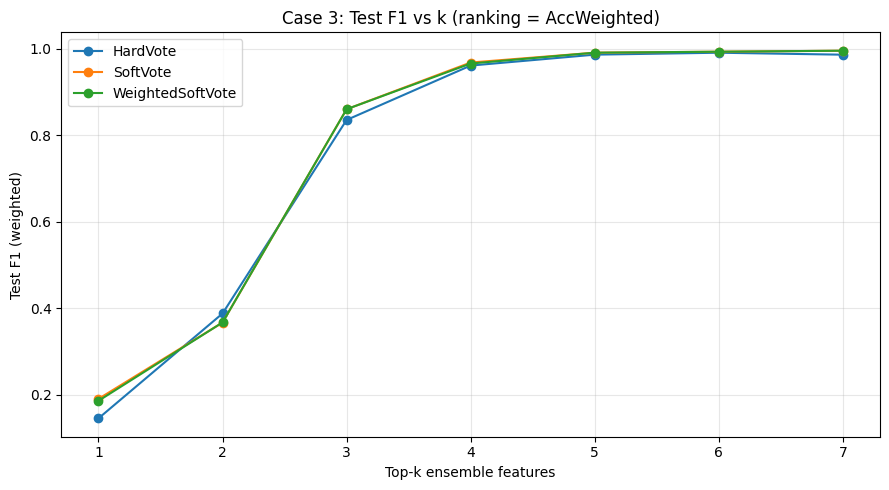

In [ ]:
# ==== Case 3 / Step 1 — Voting Ensembles on Ensemble Feature Sets ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

# ---------- Assumes already defined ----------
# X_train, X_test, y_train_encoded, y_test_encoded
# ensemble_simple_avg, ensemble_rank_avg, ensemble_acc_weighted  (from Case 2)

# ---------- Base learner builders (probability-enabled) ----------
def make_logreg():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs"))
    ])

def make_xgb():
    try:
        return XGBClassifier(**xgb.get_xgb_params(), eval_metric="mlogloss")
    except:
        return XGBClassifier(
            eval_metric="mlogloss", random_state=42,
            n_estimators=300, learning_rate=0.1, max_depth=6,
            subsample=0.9, colsample_bytree=0.9
        )

def make_rf():
    try:
        return RandomForestClassifier(**rf.get_params())
    except:
        return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

def make_svm():
    # probability=True required for soft voting
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", probability=True))
    ])

def make_mlp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000,
                              early_stopping=True, n_iter_no_change=20,
                              validation_fraction=0.1, random_state=42))
    ])

# Assemble a dict for convenience
BASE_BUILDERS = {
    "LogReg": make_logreg,
    "XGB":    make_xgb,
    "RF":     make_rf,
    "SVM":    make_svm,
    "MLP":    make_mlp,
}

# ---------- Feature ranking selector ----------
RANKINGS = {
    "SimpleAvg": ensemble_simple_avg,          # higher = better
    "RankAvg":   ensemble_rank_avg,            # lower  = better
    "AccWeighted": ensemble_acc_weighted       # higher = better
}

def ordered_features_from_series(name: str, ser: pd.Series):
    if name == "RankAvg":
        return list(ser.sort_values(ascending=True).index)
    return list(ser.sort_values(ascending=False).index)

# ---------- Weights for Weighted Soft Voting ----------
# 1) Try to read from Case 2 summary (best per model for a given strategy)
# 2) Fallback to Case 1 test accuracies if not available
CASE1_TEST_ACC_FALLBACK = {
    "LogReg": 0.975,
    "XGB":    0.993,
    "RF":     0.995,
    "SVM":    0.970,
    "MLP":    0.980
}

def get_weights_for_strategy(strategy_name: str):
    weights = {}
    try:
        # summary_case2 has columns: strategy, model, test_f1 (or test_acc)
        sub = summary_case2[summary_case2["strategy"] == strategy_name]
        if sub.empty:
            raise ValueError("No rows for strategy in summary_case2")
        for _, r in sub.iterrows():
            weights[r["model"]] = float(r["test_f1"])  # use test F1 as weight
    except Exception:
        weights = CASE1_TEST_ACC_FALLBACK.copy()
    # Normalize weights to sum=1 (not required by sklearn, but good hygiene)
    s = sum(weights.values())
    if s > 0:
        for k in weights: weights[k] = weights[k] / s
    return weights

# ---------- Runner: evaluate voting ensembles for a given ranking ----------
def run_voting_for_ranking(rank_name: str, feats_series: pd.Series):
    ordered_feats = ordered_features_from_series(rank_name, feats_series)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    rows = []

    # Build base estimators (fresh each run)
    base_models = {name: maker() for name, maker in BASE_BUILDERS.items()}
    estimators_list = [(name, mdl) for name, mdl in base_models.items()]

    # Prepare weighted-soft weights
    w = get_weights_for_strategy(rank_name)
    weights_soft = [w.get(name, 0.0) for name in base_models.keys()]

    for k in range(1, len(ordered_feats) + 1):
        feats = [f for f in ordered_feats[:k] if f in X_train.columns and f in X_test.columns]
        if not feats:
            continue
        Xtr_k, Xte_k = X_train[feats], X_test[feats]

        # --- Hard Voting ---
        hv = VotingClassifier(estimators=estimators_list, voting="hard", n_jobs=None)
        acc_cv_h = cross_val_score(hv, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
        f1_cv_h  = cross_val_score(hv, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
        hv.fit(Xtr_k, y_train_encoded)
        y_pred_h = hv.predict(Xte_k)
        acc_te_h = accuracy_score(y_test_encoded, y_pred_h)
        f1_te_h  = f1_score(y_test_encoded, y_pred_h, average="weighted")
        rows.append({
            "ranking": rank_name, "ensemble": "HardVote", "k_features": k, "features_used": feats,
            "cv_accuracy": acc_cv_h, "cv_f1_weighted": f1_cv_h,
            "test_accuracy": acc_te_h, "test_f1_weighted": f1_te_h
        })

        # --- Soft Voting (equal weights) ---
        sv = VotingClassifier(estimators=estimators_list, voting="soft", weights=None, n_jobs=None)
        acc_cv_s = cross_val_score(sv, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
        f1_cv_s  = cross_val_score(sv, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
        sv.fit(Xtr_k, y_train_encoded)
        y_pred_s = sv.predict(Xte_k)
        acc_te_s = accuracy_score(y_test_encoded, y_pred_s)
        f1_te_s  = f1_score(y_test_encoded, y_pred_s, average="weighted")
        rows.append({
            "ranking": rank_name, "ensemble": "SoftVote", "k_features": k, "features_used": feats,
            "cv_accuracy": acc_cv_s, "cv_f1_weighted": f1_cv_s,
            "test_accuracy": acc_te_s, "test_f1_weighted": f1_te_s
        })

        # --- Weighted Soft Voting (weights from Case 2 or fallback) ---
        wsv = VotingClassifier(estimators=estimators_list, voting="soft", weights=weights_soft, n_jobs=None)
        acc_cv_ws = cross_val_score(wsv, Xtr_k, y_train_encoded, scoring="accuracy", cv=cv).mean()
        f1_cv_ws  = cross_val_score(wsv, Xtr_k, y_train_encoded, scoring="f1_weighted", cv=cv).mean()
        wsv.fit(Xtr_k, y_train_encoded)
        y_pred_ws = wsv.predict(Xte_k)
        acc_te_ws = accuracy_score(y_test_encoded, y_pred_ws)
        f1_te_ws  = f1_score(y_test_encoded, y_pred_ws, average="weighted")
        rows.append({
            "ranking": rank_name, "ensemble": "WeightedSoftVote", "k_features": k, "features_used": feats,
            "cv_accuracy": acc_cv_ws, "cv_f1_weighted": f1_cv_ws,
            "test_accuracy": acc_te_ws, "test_f1_weighted": f1_te_ws,
            "weights_used": {name: round(w.get(name, 0), 4) for name in base_models.keys()}
        })

    return pd.DataFrame(rows)

# ---------- Run for all three ensemble rankings ----------
res_v_simple = run_voting_for_ranking("SimpleAvg",     RANKINGS["SimpleAvg"])
res_v_rank   = run_voting_for_ranking("RankAvg",       RANKINGS["RankAvg"])
res_v_accw   = run_voting_for_ranking("AccWeighted",   RANKINGS["AccWeighted"])

results_case3_vote = pd.concat([res_v_simple, res_v_rank, res_v_accw], ignore_index=True)
results_case3_vote = results_case3_vote.sort_values(["ranking", "ensemble", "k_features"]).reset_index(drop=True)

print("✅ Case 3 — Voting Ensemble results (head):")
display(results_case3_vote.head(15))

# ---------- Pick best k per (ranking × ensemble type) ----------
def pick_best(df):
    return (df.sort_values(
        by=["test_f1_weighted", "test_accuracy", "cv_f1_weighted", "cv_accuracy", "k_features"],
        ascending=[False, False, False, False, True]
    ).iloc[0])

best_rows = []
for (rk, ens), sub in results_case3_vote.groupby(["ranking", "ensemble"]):
    best = pick_best(sub)
    best_rows.append({
        "ranking": rk,
        "ensemble": ens,
        "best_k": int(best["k_features"]),
        "features_used": ", ".join(best["features_used"]),
        "cv_acc": float(best["cv_accuracy"]),
        "cv_f1": float(best["cv_f1_weighted"]),
        "test_acc": float(best["test_accuracy"]),
        "test_f1": float(best["test_f1_weighted"]),
        "weights_used": best.get("weights_used", None)
    })

summary_case3_vote = pd.DataFrame(best_rows).sort_values(
    by=["test_f1", "test_acc"], ascending=[False, False]
).reset_index(drop=True)

print("🏁 Case 3 — Best Voting Ensembles:")
display(summary_case3_vote)

# Optional: quick plot for one ranking (e.g., AccWeighted) comparing ensemble types
try:
    rk = "AccWeighted"
    sub = results_case3_vote[results_case3_vote["ranking"] == rk]
    plt.figure(figsize=(9,5))
    for ens in sub["ensemble"].unique():
        ss = sub[sub["ensemble"] == ens]
        plt.plot(ss["k_features"], ss["test_f1_weighted"], marker='o', label=ens)
    plt.title(f"Case 3: Test F1 vs k (ranking = {rk})")
    plt.xlabel("Top-k ensemble features")
    plt.ylabel("Test F1 (weighted)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plot skipped:", e)


Stacking ensembles

In [ ]:
# ==== Case 3 / Step 2 — Stacking Ensemble ====

from sklearn.ensemble import StackingClassifier

# ---------- Base learners (re-usable) ----------
logreg = make_logreg()
rf = make_rf()
svm = make_svm()
mlp = make_mlp()
xgb = make_xgb()

# ---------- Define stacking ensemble ----------
# Meta-model: Logistic Regression (simple, interpretable)
stacking_ensemble = StackingClassifier(
    estimators=[
        ("logreg", logreg),
        ("rf", rf),
        ("svm", svm),
        ("mlp", mlp),
        ("xgb", xgb),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",  # ensures probability output
    n_jobs=-1,
)

# ---------- Train stacking ensemble ----------
stacking_ensemble.fit(X_train, y_train_encoded)

# ---------- Evaluate ----------
y_pred_stack = stacking_ensemble.predict(X_test)
y_proba_stack = stacking_ensemble.predict_proba(X_test)

acc_stack = accuracy_score(y_test_encoded, y_pred_stack)
f1_stack = f1_score(y_test_encoded, y_pred_stack, average="weighted")

print("\n=== Stacking Ensemble Performance ===")
print(f"Accuracy: {acc_stack:.4f}")
print(f"F1 Score: {f1_stack:.4f}")



=== Stacking Ensemble Performance ===
Accuracy: 0.9955
F1 Score: 0.9955


Blending ensembler

In [ ]:
# ==== Case 3 / Step 3 — Blending Ensemble (hold-out meta set) ====

import numpy as np
from collections import OrderedDict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# --- Utilities ---
def safe_auc(y_true, proba):
    try:
        if proba.ndim == 1:  # safety: if somehow got a single column
            return np.nan
        if proba.shape[1] == 2:
            return roc_auc_score(y_true, proba[:, 1])
        else:
            return roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")
    except Exception:
        return np.nan

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

# --- Ensure base estimators exist ---
try:
    base_estimators  # noqa
except NameError:
    # Build from your Step 1/2 factory functions
    logreg = make_logreg()
    rf     = make_rf()
    svm    = make_svm()
    mlp    = make_mlp()
    xgb    = make_xgb()
    base_estimators = OrderedDict([
        ("logreg", logreg),
        ("rf", rf),
        ("svm", svm),
        ("mlp", mlp),
        ("xgb", xgb),
    ])

# --- Split training into base-fit vs meta-learn sets ---
X_base, X_meta, y_base, y_meta = train_test_split(
    X_train, y_train_encoded,
    test_size=0.2, stratify=y_train_encoded, random_state=42
)

# --- Fit base models on base-split and create meta-features ---
fitted_bases = {}
meta_feats_valid = []
meta_feats_test  = []

for name, est in base_estimators.items():
    est.fit(X_base, y_base)
    fitted_bases[name] = est

    if hasattr(est, "predict_proba"):
        pv = est.predict_proba(X_meta)
        pt = est.predict_proba(X_test)
    else:
        # Rare fallback (SVC already has proba=True in our setup)
        dv = est.decision_function(X_meta)
        dt = est.decision_function(X_test)
        if dv.ndim == 1:
            dv = np.vstack([1 - dv, dv]).T
            dt = np.vstack([1 - dt, dt]).T
        pv = softmax(dv)
        pt = softmax(dt)

    meta_feats_valid.append(pv)
    meta_feats_test.append(pt)

# Concatenate all base-model probabilities → meta-learner inputs
Z_valid = np.concatenate(meta_feats_valid, axis=1)
Z_test  = np.concatenate(meta_feats_test,  axis=1)

# --- Meta-learner (LogReg). You can swap to XGB/LightGBM later if needed. ---
meta_lr = LogisticRegression(max_iter=3000)
meta_lr.fit(Z_valid, y_meta)

# --- Evaluate on the original test set ---
y_pred_blend  = meta_lr.predict(Z_test)
acc_blend     = accuracy_score(y_test_encoded, y_pred_blend)
f1_blend      = f1_score(y_test_encoded, y_pred_blend, average="weighted")

try:
    y_proba_blend = meta_lr.predict_proba(Z_test)
    auc_blend     = safe_auc(y_test_encoded, y_proba_blend)
except Exception:
    auc_blend = np.nan

print("\n=== Step 3 — Blending (LR meta, 20% hold-out) ===")
print(f"Accuracy : {acc_blend:.4f}")
print(f"F1 (wgt) : {f1_blend:.4f}")
print(f"AUC      : {auc_blend:.4f}" if not np.isnan(auc_blend) else "AUC      : n/a")

# --- Optional: persist meta + base models together (uncomment if desired) ---
# from joblib import dump
# dump({"meta": meta_lr, "bases": fitted_bases}, "blending_ensemble.joblib")



=== Step 3 — Blending (LR meta, 20% hold-out) ===
Accuracy : 0.9932
F1 (wgt) : 0.9932
AUC      : 1.0000


Final results

In [ ]:
# ==== Case 3 — Step 4 & Step 5 with Final Results ====

import time
import numpy as np
import pandas as pd
from collections import OrderedDict

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# ---------------------------
# Utilities
# ---------------------------
def safe_auc(y_true, proba):
    try:
        if proba.ndim == 1:
            return np.nan
        if proba.shape[1] == 2:
            return roc_auc_score(y_true, proba[:, 1])
        else:
            return roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")
    except Exception:
        return np.nan

def evaluate_from_proba(name, y_true, proba):
    """Evaluate metrics when you already have class probabilities."""
    y_pred = np.argmax(proba, axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = safe_auc(y_true, proba)
    return {"model": name, "accuracy": acc, "f1_weighted": f1w, "auc": auc}

def ensure_base_estimators():
    """Build base estimators if base_estimators not present."""
    try:
        base_estimators  # noqa: F821
        return base_estimators
    except NameError:
        logreg = make_logreg()
        rf     = make_rf()
        svm    = make_svm()
        mlp    = make_mlp()
        xgb    = make_xgb()
        return OrderedDict([
            ("logreg", logreg),
            ("rf", rf),
            ("svm", svm),
            ("mlp", mlp),
            ("xgb", xgb),
        ])

def cv_accuracy_weight(model, X, y, cvsplits):
    scores = cross_val_score(model, X, y, cv=cvsplits, scoring="accuracy", n_jobs=-1)
    return scores.mean()

# ---------------------------
# (Re)Create required models if missing
# ---------------------------
base_estimators = ensure_base_estimators()

# 1) CV-weighted Soft Voting (we’ll need its probabilities later)
try:
    voting_soft_weighted  # noqa
except NameError:
    print("[Rebuild] Voting-Soft-CVWeighted ...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    weights = []
    for name, est in base_estimators.items():
        weights.append(cv_accuracy_weight(est, X_train, y_train_encoded, cv))
    weights = np.array(weights)
    if np.allclose(weights.sum(), 0):  # safety
        weights = np.ones_like(weights)
    voting_soft_weighted = VotingClassifier(
        estimators=list(base_estimators.items()),
        voting="soft",
        weights=weights,
        n_jobs=-1
    )
    voting_soft_weighted.fit(X_train, y_train_encoded)

# 2) Stacking (LogReg meta) if missing
try:
    stacking_ensemble  # noqa
except NameError:
    print("[Rebuild] Stacking (LR meta) ...")
    stacking_ensemble = StackingClassifier(
        estimators=list(base_estimators.items()),
        final_estimator=LogisticRegression(max_iter=2000),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        stack_method="predict_proba",
        n_jobs=-1,
    )
    stacking_ensemble.fit(X_train, y_train_encoded)

# 3) Blending assets from Step 3 (meta_lr + fitted_bases). If missing, build quickly.
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def build_or_use_blending():
    global meta_lr, fitted_bases, Z_valid, Z_test, y_meta  # for reuse in reporting
    try:
        meta_lr, fitted_bases  # noqa
        # Assume Z_test is available; if not, compute it now.
    except NameError:
        print("[Rebuild] Blending (LR meta, 20% hold-out) ...")
        X_base, X_meta, y_base, y_meta_local = train_test_split(
            X_train, y_train_encoded,
            test_size=0.2, stratify=y_train_encoded, random_state=42
        )
        fitted_bases = {}
        meta_feats_valid, meta_feats_test = [], []
        for name, est in base_estimators.items():
            est.fit(X_base, y_base)
            fitted_bases[name] = est
            if hasattr(est, "predict_proba"):
                meta_feats_valid.append(est.predict_proba(X_meta))
                meta_feats_test.append(est.predict_proba(X_test))
            else:
                dv = est.decision_function(X_meta); dt = est.decision_function(X_test)
                if dv.ndim == 1:
                    dv = np.vstack([1 - dv, dv]).T
                    dt = np.vstack([1 - dt, dt]).T
                meta_feats_valid.append(softmax(dv))
                meta_feats_test.append(softmax(dt))
        Z_valid_local = np.concatenate(meta_feats_valid, axis=1)
        Z_test_local  = np.concatenate(meta_feats_test,  axis=1)
        meta_lr_local = LogisticRegression(max_iter=3000)
        meta_lr_local.fit(Z_valid_local, y_meta_local)
        # expose
        meta_lr = meta_lr_local
        Z_valid, Z_test, y_meta = Z_valid_local, Z_test_local, y_meta_local

    # If Z_test not defined (e.g., you had meta_lr/fitted_bases but not matrices), compute:
    try:
        Z_test  # noqa
    except NameError:
        meta_feats_test = []
        for name, est in fitted_bases.items():
            if hasattr(est, "predict_proba"):
                meta_feats_test.append(est.predict_proba(X_test))
            else:
                dt = est.decision_function(X_test)
                if dt.ndim == 1:
                    dt = np.vstack([1 - dt, dt]).T
                meta_feats_test.append(softmax(dt))
        Z_test_local  = np.concatenate(meta_feats_test, axis=1)
        Z_test = Z_test_local

build_or_use_blending()

# ---------------------------
# STEP 4 — Super-Ensemble (Average of Ensembles)
# ---------------------------
print("\n[Step 4] Super-Ensemble: averaging probabilities of (Voting-CVWeighted, Stacking, Blending)")

# Get probabilities from each ensemble on TEST set
proba_vote = voting_soft_weighted.predict_proba(X_test)

proba_stack = stacking_ensemble.predict_proba(X_test)

# Blending probabilities on TEST set
proba_blend = meta_lr.predict_proba(Z_test)

# Uniform average (simple and robust). You can weight by their meta/validation F1 if desired.
proba_super = (proba_vote + proba_stack + proba_blend) / 3.0

# Evaluate each and the super-ensemble
results = []

# Individual ensemble evaluations
results.append(evaluate_from_proba("Voting-Soft-CVWeighted", y_test_encoded, proba_vote))
results.append(evaluate_from_proba("Stacking (LR meta)",       y_test_encoded, proba_stack))
results.append(evaluate_from_proba("Blending (LR meta)",       y_test_encoded, proba_blend))

# Super-ensemble
results.append(evaluate_from_proba("Super-Ensemble (avg of 3)", y_test_encoded, proba_super))

# ---------------------------
# STEP 5 — Final Results, Reports, and Artifacts
# ---------------------------
df_results = pd.DataFrame(results).sort_values(by="f1_weighted", ascending=False).reset_index(drop=True)
print("\n=== FINAL LEADERBOARD (sorted by F1 weighted) ===")
print(df_results.to_string(index=False))

# Pick the best by F1 (weighted)
best_name = df_results.iloc[0]["model"]
print(f"\nBest model by F1(w): {best_name}")

# Build predicted labels for the best to print reports
if best_name == "Voting-Soft-CVWeighted":
    y_pred_best = np.argmax(proba_vote, axis=1)
    proba_best  = proba_vote
elif best_name == "Stacking (LR meta)":
    y_pred_best = np.argmax(proba_stack, axis=1)
    proba_best  = proba_stack
elif best_name == "Blending (LR meta)":
    y_pred_best = np.argmax(proba_blend, axis=1)
    proba_best  = proba_blend
else:  # Super-Ensemble
    y_pred_best = np.argmax(proba_super, axis=1)
    proba_best  = proba_super

# Classification report & Confusion matrix
print("\n=== Classification Report (Best Model) ===")
print(classification_report(y_test_encoded, y_pred_best, digits=4))

print("=== Confusion Matrix (Best Model) ===")
print(confusion_matrix(y_test_encoded, y_pred_best))

# Save leaderboard
timestamp = time.strftime("%Y%m%d_%H%M%S")
df_results.to_csv(f"ensemble_final_leaderboard_{timestamp}.csv", index=False)
print(f"\nSaved leaderboard → ensemble_final_leaderboard_{timestamp}.csv")

# Optional: persist models (commented to avoid large writes by default)
# from joblib import dump
# dump(voting_soft_weighted, f"model_voting_cvweighted_{timestamp}.joblib")
# dump(stacking_ensemble,   f"model_stacking_lrmeta_{timestamp}.joblib")
# dump({"meta": meta_lr, "bases": fitted_bases}, f"model_blending_lrmeta_{timestamp}.joblib")
# np.save(f"proba_super_{timestamp}.npy", proba_super)


[Rebuild] Voting-Soft-CVWeighted ...

[Step 4] Super-Ensemble: averaging probabilities of (Voting-CVWeighted, Stacking, Blending)

=== FINAL LEADERBOARD (sorted by F1 weighted) ===
                    model  accuracy  f1_weighted      auc
   Voting-Soft-CVWeighted  0.995455     0.995452 0.999995
       Stacking (LR meta)  0.995455     0.995452 1.000000
Super-Ensemble (avg of 3)  0.995455     0.995452 1.000000
       Blending (LR meta)  0.993182     0.993169 1.000000

Best model by F1(w): Voting-Soft-CVWeighted

=== Classification Report (Best Model) ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        20
           1     1.0000    1.0000    1.0000        20
           2     1.0000    1.0000    1.0000        20
           3     1.0000    1.0000    1.0000        20
           4     1.0000    1.0000    1.0000        20
           5     1.0000    1.0000    1.0000        20
           6     1.0000    1.0000    1.0000        20
       